In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [2]:
dataset_url = (
    "https://raw.githubusercontent.com/"
    "datasciencedojo/datasets/master/titanic.csv"
)

data_path = Path("../data/titanic.csv")
data_path.parent.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(dataset_url)
df.to_csv(data_path, index=False)

print(f"Dataset guardado en: {data_path}")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.head()

Dataset guardado en: ..\data\titanic.csv
Filas: 891
Columnas: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Dimensiones del dataset:")
print(df.shape)

print("\nNombres de las columnas:")
print(df.columns.tolist())

print("\nInformación general:")
df.info()

Dimensiones del dataset:
(891, 12)

Nombres de las columnas:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [4]:
missing_values = pd.DataFrame({
    "Valores nulos": df.isnull().sum(),
    "Porcentaje": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[
    missing_values["Valores nulos"] > 0
].sort_values(by="Valores nulos", ascending=False)

missing_values

,Valores nulos,Porcentaje
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [5]:
survival_counts = df["Survived"].value_counts().sort_index()

survival_summary = pd.DataFrame({
    "Cantidad": survival_counts,
    "Porcentaje": (
        df["Survived"].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

survival_summary.index = ["No sobrevivió", "Sobrevivió"]

survival_summary

,Cantidad,Porcentaje
No sobrevivió,549,61.62
Sobrevivió,342,38.38


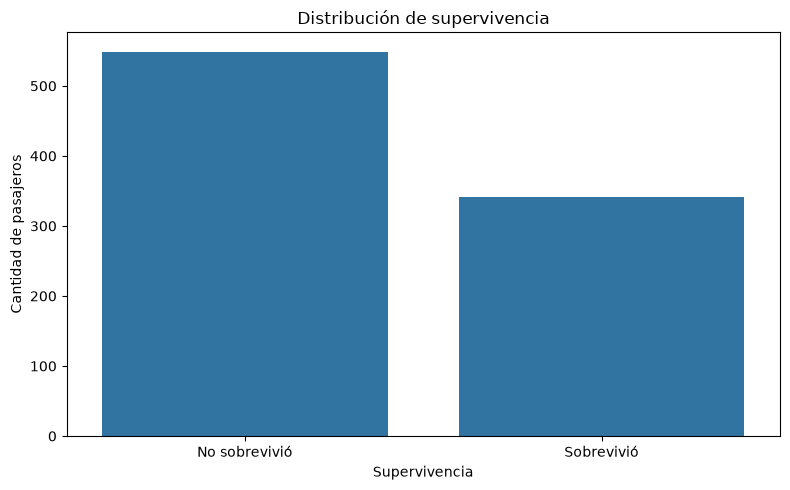

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Survived"
)

plt.title("Distribución de supervivencia")
plt.xlabel("Supervivencia")
plt.ylabel("Cantidad de pasajeros")
plt.xticks(
    ticks=[0, 1],
    labels=["No sobrevivió", "Sobrevivió"]
)

plt.tight_layout()
plt.show()

In [7]:
survival_by_sex = pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
) * 100

survival_by_sex.columns = [
    "No sobrevivió",
    "Sobrevivió"
]

survival_by_sex.round(2)

,No sobrevivió,Sobrevivió
Sex,,
female,25.80,74.20
male,81.11,18.89


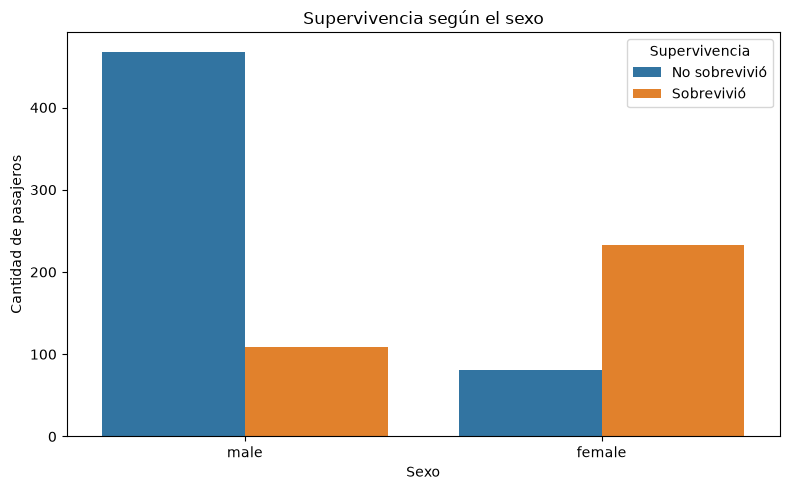

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)

plt.title("Supervivencia según el sexo")
plt.xlabel("Sexo")
plt.ylabel("Cantidad de pasajeros")
plt.legend(
    title="Supervivencia",
    labels=["No sobrevivió", "Sobrevivió"]
)

plt.tight_layout()
plt.show()

In [9]:
survival_by_class = pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
) * 100

survival_by_class.columns = [
    "No sobrevivió",
    "Sobrevivió"
]

survival_by_class.round(2)

,No sobrevivió,Sobrevivió
Pclass,,
1,37.04,62.96
2,52.72,47.28
3,75.76,24.24


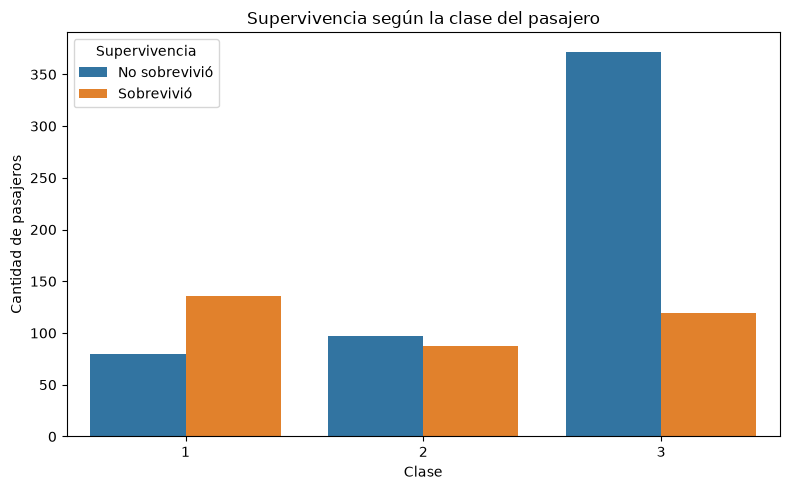

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)

plt.title("Supervivencia según la clase del pasajero")
plt.xlabel("Clase")
plt.ylabel("Cantidad de pasajeros")
plt.legend(
    title="Supervivencia",
    labels=["No sobrevivió", "Sobrevivió"]
)

plt.tight_layout()
plt.show()

In [11]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

target = "Survived"

X = df[features].copy()
y = df[target].copy()

print("Variables utilizadas:")
print(X.columns.tolist())

print("\nDimensiones de X:")
print(X.shape)

print("\nDimensiones de y:")
print(y.shape)

X.head()

Variables utilizadas:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Dimensiones de X:
(891, 7)

Dimensiones de y:
(891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:")
print(X_train.shape)

print("\nDatos de prueba:")
print(X_test.shape)

print("\nDistribución del objetivo en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribución del objetivo en prueba:")
print(y_test.value_counts(normalize=True).round(3))

Datos de entrenamiento:
(712, 7)

Datos de prueba:
(179, 7)

Distribución del objetivo en entrenamiento:
Survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Distribución del objetivo en prueba:
Survived
0    0.615
1    0.385
Name: proportion, dtype: float64


In [13]:
numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked"
]

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['Age', 'SibSp', 'Parch', 'Fare']

Variables categóricas:
['Pclass', 'Sex', 'Embarked']


In [14]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocesamiento creado correctamente")

Preprocesamiento creado correctamente


In [15]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_pipeline.fit(
    X_train,
    y_train
)

print("Modelo de Regresión Logística entrenado correctamente")

Modelo de Regresión Logística entrenado correctamente


In [16]:
logistic_predictions = logistic_pipeline.predict(X_test)

logistic_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

print("Resultados de Regresión Logística")
print("-" * 40)
print(f"Accuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1-score:  {logistic_f1:.4f}")
print(f"ROC-AUC:   {logistic_roc_auc:.4f}")

Resultados de Regresión Logística
----------------------------------------
Accuracy:  0.8045
Precision: 0.7931
Recall:    0.6667
F1-score:  0.7244
ROC-AUC:   0.8427


In [17]:
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=[
            "No sobrevivió",
            "Sobrevivió"
        ]
    )
)

               precision    recall  f1-score   support

No sobrevivió       0.81      0.89      0.85       110
   Sobrevivió       0.79      0.67      0.72        69

     accuracy                           0.80       179
    macro avg       0.80      0.78      0.79       179
 weighted avg       0.80      0.80      0.80       179



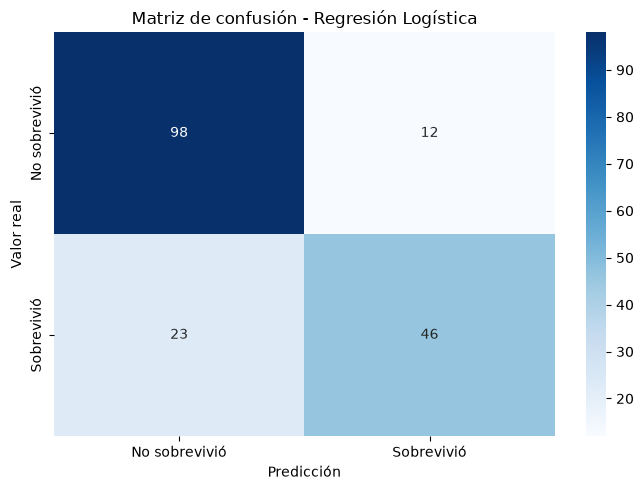

In [18]:
logistic_confusion_matrix = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    logistic_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No sobrevivió",
        "Sobrevivió"
    ],
    yticklabels=[
        "No sobrevivió",
        "Sobrevivió"
    ]
)

plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.tight_layout()
plt.show()

In [19]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=6,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Modelo Random Forest entrenado correctamente")

Modelo Random Forest entrenado correctamente


In [20]:
random_forest_predictions = random_forest_pipeline.predict(X_test)

random_forest_probabilities = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

random_forest_precision = precision_score(
    y_test,
    random_forest_predictions
)

random_forest_recall = recall_score(
    y_test,
    random_forest_predictions
)

random_forest_f1 = f1_score(
    y_test,
    random_forest_predictions
)

random_forest_roc_auc = roc_auc_score(
    y_test,
    random_forest_probabilities
)

print("Resultados de Random Forest")
print("-" * 40)
print(f"Accuracy:  {random_forest_accuracy:.4f}")
print(f"Precision: {random_forest_precision:.4f}")
print(f"Recall:    {random_forest_recall:.4f}")
print(f"F1-score:  {random_forest_f1:.4f}")
print(f"ROC-AUC:   {random_forest_roc_auc:.4f}")

Resultados de Random Forest
----------------------------------------
Accuracy:  0.8045
Precision: 0.7297
Recall:    0.7826
F1-score:  0.7552
ROC-AUC:   0.8405


In [21]:
print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=[
            "No sobrevivió",
            "Sobrevivió"
        ]
    )
)

               precision    recall  f1-score   support

No sobrevivió       0.86      0.82      0.84       110
   Sobrevivió       0.73      0.78      0.76        69

     accuracy                           0.80       179
    macro avg       0.79      0.80      0.80       179
 weighted avg       0.81      0.80      0.81       179



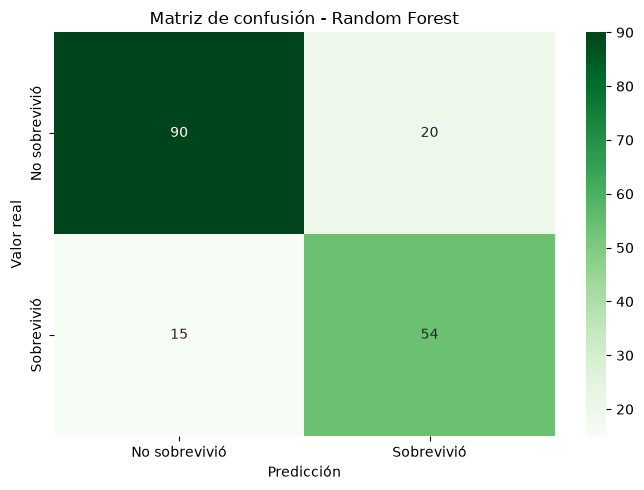

In [22]:
random_forest_confusion_matrix = confusion_matrix(
    y_test,
    random_forest_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    random_forest_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=[
        "No sobrevivió",
        "Sobrevivió"
    ],
    yticklabels=[
        "No sobrevivió",
        "Sobrevivió"
    ]
)

plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.tight_layout()
plt.show()

In [23]:
model_comparison = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        random_forest_accuracy
    ],
    "Precision": [
        logistic_precision,
        random_forest_precision
    ],
    "Recall": [
        logistic_recall,
        random_forest_recall
    ],
    "F1-score": [
        logistic_f1,
        random_forest_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        random_forest_roc_auc
    ]
})

model_comparison = model_comparison.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

model_comparison.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.8045,0.7297,0.7826,0.7552,0.8405
1,Regresión Logística,0.8045,0.7931,0.6667,0.7244,0.8427


In [24]:
if random_forest_f1 >= logistic_f1:
    best_model = random_forest_pipeline
    best_model_name = "Random Forest"
else:
    best_model = logistic_pipeline
    best_model_name = "Regresión Logística"

model_path = Path("../models/titanic_survival_model.joblib")
model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, model_path)

print(f"Mejor modelo: {best_model_name}")
print(f"Modelo guardado en: {model_path}")

Mejor modelo: Random Forest
Modelo guardado en: ..\models\titanic_survival_model.joblib


In [25]:
loaded_model = joblib.load(
    "../models/titanic_survival_model.joblib"
)

sample_passenger = pd.DataFrame({
    "Pclass": [1],
    "Sex": ["female"],
    "Age": [29],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [80],
    "Embarked": ["C"]
})

sample_prediction = loaded_model.predict(
    sample_passenger
)[0]

sample_probability = loaded_model.predict_proba(
    sample_passenger
)[0][1]

result = (
    "Sobrevivió"
    if sample_prediction == 1
    else "No sobrevivió"
)

print(f"Predicción: {result}")
print(
    f"Probabilidad de supervivencia: "
    f"{sample_probability:.2%}"
)

Predicción: Sobrevivió
Probabilidad de supervivencia: 99.16%


In [26]:
loaded_model = joblib.load(
    "../models/titanic_survival_model.joblib"
)

sample_passenger = pd.DataFrame({
    "Pclass": [1],
    "Sex": ["female"],
    "Age": [29],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [80],
    "Embarked": ["C"]
})

sample_prediction = loaded_model.predict(
    sample_passenger
)[0]

sample_probability = loaded_model.predict_proba(
    sample_passenger
)[0][1]

result = (
    "Sobrevivió"
    if sample_prediction == 1
    else "No sobrevivió"
)

print(f"Predicción: {result}")
print(
    f"Probabilidad de supervivencia: "
    f"{sample_probability:.2%}"
)

Predicción: Sobrevivió
Probabilidad de supervivencia: 99.16%
